# Base escolhida: Medical Appointment No Shows.csv

## Questão 1

**Cenário:** Classificação Binária Supervisionada.

**Justificativa:** O objetivo central é prever se um paciente irá comparecer ou não à consulta, utilizando o atributo alvo `No-show`.

* **Classificação:** A variável dependente é categórica (discreta) e não um valor numérico contínuo.
* **Supervisionada:** O modelo aprenderá a partir de dados históricos que já possuem os rótulos (resultados) conhecidos.
* **Binária:** Como existem apenas duas classes possíveis na base ("Yes" ou "No"), o problema é definido especificamente como classificação binária.

In [1]:
import pandas as pd
import numpy as np

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

path = 'Medical Appointment No Shows.csv'
df = pd.read_csv(path)

df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


## Código reutilizavel de diagnostico
#### diagnostico_inicial(data)

In [3]:
import pandas as pd
import numpy as np

# @title Questão 1: Diagnóstico Inicial Automatizado
# Base: Medical Appointment No Shows

def diagnosis(df):
    print("=== DIAGNÓSTICO ESTRUTURAL DA BASE ===\n")

    # 1. Dimensões
    print(f"Dimensões: {df.shape[0]} linhas e {df.shape[1]} colunas.")

    # 2. Tipos, Nulos e Cardinalidade para todas as colunas
    print("\n--- Resumo de Atributos ---")
    info = pd.DataFrame({
        'Tipo de Dado': df.dtypes,
        'Valores Ausentes': df.isnull().sum(),
        'Valores Únicos (Cardinalidade)': df.nunique()
    })
    print(info)

    # 3. Duplicidades
    duplicados = df.duplicated().sum()
    print(f"\nTotal de registros duplicados: {duplicados}")

    # 4. Possíveis Inconsistências de Leitura/Estrutura
    print("\n--- Inconsistências de Leitura Identificadas ---")

    # Verificando IDs que podem ter sido lidos como floats devido ao tamanho
    for col in ['PatientId', 'AppointmentID']:
        if col in df.columns and df[col].dtype == 'float64':
            print(f"[!] Alerta: Coluna '{col}' lida como float. Pode haver perda de precisão ou erro de formato.")

    # Verificando datas lidas como 'object' (texto) em vez de datetime
    datas_em_texto = [col for col in df.columns if 'Day' in col and df[col].dtype == 'object']
    if datas_em_texto:
        print(f"\n[!] INCONSISTÊNCIA DE LEITURA: Colunas de data detectadas como 'object' (texto): {datas_em_texto}")
        for col in datas_em_texto:
            exemplo_valor = df[col].iloc
            print(f"A coluna '{col}' contém valores como '{exemplo_valor}', mas foi lida como string.")

    # Verificando se o ID da consulta é realmente único para todas as classes
    if 'AppointmentID' in df.columns:
        is_unique = df['AppointmentID'].is_unique
        print(f"[*] A chave primária (AppointmentID) é única? {is_unique}")

diagnosis(df)

=== DIAGNÓSTICO ESTRUTURAL DA BASE ===

Dimensões: 110527 linhas e 14 colunas.

--- Resumo de Atributos ---
               Tipo de Dado  Valores Ausentes  Valores Únicos (Cardinalidade)
PatientId           float64                 0                           62299
AppointmentID         int64                 0                          110527
Gender                  str                 0                               2
ScheduledDay            str                 0                          103549
AppointmentDay          str                 0                              27
Age                   int64                 0                             104
Neighbourhood           str                 0                              81
Scholarship           int64                 0                               2
Hipertension          int64                 0                               2
Diabetes              int64                 0                               2
Alcoholism            int64       

# Questão 2

Esta auditoria identifica falhas técnicas e de preenchimento que precisam de correção antes da modelagem.

### Checklist de Auditoria:

* **Valores implausíveis:** ✅ **Feito.** Identificada 1 linha com idade negativa (-1).
* **Tipos inadequados:** ✅ **Feito.** Colunas de data (`ScheduledDay` e `AppointmentDay`) lidas como texto e IDs lidos como *float*.
* **Categorias raras:** ✅ **Feito.** Identificadas categorias com menos de 1% da base em `Handcap`, `Age` e `Neighbourhood`.
* **Padrões suspeitos:** ✅ **Feito.** Verificado que muitos pacientes possuem múltiplos agendamentos (reconsultas).
* **Outliers:** ✅ **Feito.** Identificados 5 pacientes com idade acima de 110.
* **Inconsistências lógicas:** ✅ **Feito.** Detectadas 5 consultas marcadas para antes da data do agendamento.
* **Coerência temporal:** ✅ **Feito.** Verificada a ordem cronológica entre registro e consulta.
* **Valores monetários:** ❌ **Não se aplica.** A base não contém dados financeiros.

### Resumo dos Problemas:
1. **Datas:** Precisam de conversão para o formato correto e exclusão de 5 registros retroativos.
2. **Idade:** Necessário remover o registro de -1 ano e avaliar os 5 casos maiores de 110.
3. **Categorias:** Níveis 2, 3 e 4 de `Handcap` são raros e podem ser agrupados.

In [4]:
def implausiveis(data):
    print("Valores Implausíveis\n")
    total_problemas = 0

    # 1. Identificadores (IDs): Não devem ser negativos ou zero
    for col in ['PatientId', 'AppointmentID']:
        impl_ids = (data[col] <= 0).sum()
        if impl_ids > 0:
            print(f"[!] {col}: {impl_ids} registros com ID inválido (<= 0).")
            total_problemas += impl_ids

    # 2. Gênero: Deve ser apenas 'F' ou 'M'
    impl_gender = (~data['Gender'].isin(['F', 'M'])).sum()
    if impl_gender > 0:
        print(f"[!] Gender: {impl_gender} valores fora de ['F', 'M'].")
        total_problemas += impl_gender

    # 3. Idade: Não pode ser negativa
    impl_age = (data['Age'] < 0).sum()
    if impl_age > 0:
        print(f"[!] Age: {impl_age} registros com idade negativa.")
        total_problemas += impl_age

    # 4. Atributos Binários: Verificando se há algo diferente de 0 ou 1
    cols_binarias = ['Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'SMS_received']
    for col in cols_binarias:
        inconsistentes = ( (data[col] != 0) & (data[col] != 1) ).sum()
        if inconsistentes > 0:
            print(f"[!] {col}: {inconsistentes} registros com valores fora de [0, 1].")
            total_problemas += inconsistentes

    # 5. Handcap: Intervalo esperado de 0 a 4
    handcap_fora = ((data['Handcap'] < 0) | (data['Handcap'] > 4)).sum()
    if handcap_fora > 0:
        print(f"[!] Handcap: {handcap_fora} registros fora do intervalo 0-4.")
        total_problemas += handcap_fora

    # 6. Alvo (No-show): Deve ser apenas 'Yes' ou 'No'
    impl_noshow = (~data['No-show'].isin(['Yes', 'No'])).sum()
    if impl_noshow > 0:
        print(f"[!] No-show (Alvo): {impl_noshow} valores inesperados.")
        total_problemas += impl_noshow

In [5]:
def tipos_inadequados(data):
    print("Tipos de Dados Inadequados \n")
    # 1. Verificando se os IDs foram lidos como floats (comum para PatientId)
    for col in ['PatientId', 'AppointmentID']:
        if col in data.columns and data[col].dtype == 'float64':
            print(f"[!] Alerta: Coluna '{col}' lida como float. Pode haver perda de precisão ou erro de formato.")

    # 2. Verificando se colunas de data foram lidas como strings (object)
    # Na estrutura da base, ScheduledDay e AppointmentDay são as datas [2]
    for col in ['ScheduledDay', 'AppointmentDay']:
        if col in data.columns and (data[col].dtype == 'str' or data[col].dtype == 'object' or data[col].dtype == 'obj'):
            # .iloc[0] pega o valor real da primeira linha, evitando o erro de exibição do objeto indexador
            exemplo = data[col].iloc[0]
            print(f"[!] Alerta: Coluna '{col}' lida como texto (object), mas deveria ser 'datetime'.")
            print(f"    Valor de exemplo: {exemplo}")

In [6]:
def categorias_raras(data):
    print("Categorias Raras (< 1% da base)\n")
    n_linhas = data.shape[0]
    limite_raro = 0.01 * n_linhas

    for col in data.columns:
        if col in ['PatientId', 'AppointmentID']:
            continue
        contagem = data[col].value_counts()

        categorias_raras_detectadas = contagem[contagem < limite_raro]

        if not categorias_raras_detectadas.empty:
            total_pacientes = categorias_raras_detectadas.sum()
            qtd_categorias = len(categorias_raras_detectadas)

            print(f"[!] {col}: {qtd_categorias} categorias raras que afetam {total_pacientes} pacientes.")
            if qtd_categorias < 5:
                print(f"    Categorias: {categorias_raras_detectadas.index.tolist()}")

In [7]:
def padroes_suspeitos_preenchimento(data):
    print("Padrões Suspeitos de Preenchimento\n")

    # 1. IDs de Pacientes Duplicados
    # Ter o mesmo PatientId é normal (retorno), mas ajuda a entender o comportamento
    pacientes_repetidos = data['PatientId'].duplicated().sum()
    if pacientes_repetidos > 0:
        print(f"[!] PatientId: {pacientes_repetidos} registos de pacientes que já apareceram antes (reconsultas).")

    # 2. IDs de Agendamento Duplicados (Isso seria um erro grave de integridade)
    agendamentos_duplicados = data['AppointmentID'].duplicated().sum()
    if agendamentos_duplicados > 0:
        print(f"[!] AppointmentID: {agendamentos_duplicados} IDs de agendamento duplicados detectados!")

    # 3. Concentração Excessiva em uma Categoria (Bias de preenchimento)
    # Se uma categoria domina > 95% da base, pode ser um preenchimento "padrão" automático
    for col in data.select_dtypes(include=['object', 'int64', 'string']).columns:
        if col not in ['PatientId', 'AppointmentID', 'No-show']:
            top_val = data[col].value_counts(normalize=True).iloc[0]
            if top_val > 0.95:
                nome_cat = data[col].value_counts().index[0]
                print(f"[!] {col}: Padrão suspeito de 'valor padrão'. {top_val*100:.1f}% dos dados são '{nome_cat}'.")

    # 4. Horários de Agendamento (ScheduledDay) no mesmo segundo
    # Muitos agendamentos no mesmíssimo segundo podem indicar importação em lote (bots/scripts)
    if 'ScheduledDay' in data.columns:
        mesmo_segundo = data['ScheduledDay'].duplicated().sum()
        if mesmo_segundo > 500: # Limite arbitrário para alerta
            print(f"[!] ScheduledDay: {mesmo_segundo} agendamentos feitos no exato segundo de outro registo.")

In [8]:
def outliers(data):
    print("--- Auditoria: Detecção de Outliers (Regra do IQR) --- \n")

    # Selecionamos apenas colunas numéricas que não sejam IDs ou Binárias
    # 'Age' é a principal candidata, 'Handcap' é categórica ordinal (0-4)
    colunas_numericas = ['Age']

    for col in colunas_numericas:
        if col in data.columns:
            # Cálculo do IQR
            Q1 = data[col].quantile(0.25)
            Q3 = data[col].quantile(0.75)
            IQR = Q3 - Q1

            # Definição dos limites (Padrão: 1.5 * IQR)
            limite_inferior = Q1 - 1.5 * IQR
            limite_superior = Q3 + 1.5 * IQR

            # Identificação
            outliers_sup = data[data[col] > limite_superior]
            outliers_inf = data[data[col] < limite_inferior]
            total_outliers = len(outliers_sup) + len(outliers_inf)

            if total_outliers > 0:
                print(f"[!] {col}: detectados {total_outliers} possíveis outliers.")
                print(f"    Limite Superior: {limite_superior} | Valor Máximo: {data[col].max()}")
                print(f"    Limite Inferior: {limite_inferior} | Valor Mínimo: {data[col].min()}")

                if not outliers_sup.empty:
                    print(f"    Exemplos de valores altos: {outliers_sup[col].unique()[:5]}")
            else:
                print(f"[-] {col}: Nenhum outlier detectado pela regra do IQR.")

In [9]:
def inconsistencias_logicas(data):
    print("Inconsistências Lógicas\n")
    total_conflitos = 0

    # 1. Coerência Temporal (Regra: AppointmentDay >= ScheduledDay)
    if 'ScheduledDay' in data.columns and 'AppointmentDay' in data.columns:
        # Convertemos temporariamente para data (sem hora) para comparar os dias
        s_day = pd.to_datetime(data['ScheduledDay']).dt.date
        a_day = pd.to_datetime(data['AppointmentDay']).dt.date

        # Consultas marcadas para o passado em relação ao agendamento
        retroativas = (a_day < s_day).sum()

        if retroativas > 0:
            print(f"[!] Datas: {retroativas} consultas agendadas para datas retroativas (impossível).")
            total_conflitos += retroativas

    # 2. Idade vs Atributos de Saúde (Ex: Recém-nascidos com Hipertensão/Alcoolismo)
    # Embora raro, é um padrão suspeito para bebês (Age <= 1)
    if 'Age' in data.columns:
        bebes_com_vicio = data[(data['Age'] <= 1) & (data['Alcoholism'] == 1)].shape[0]
        bebes_com_hiper = data[(data['Age'] <= 1) & (data['Hipertension'] == 1)].shape[0]

        if bebes_com_vicio > 0:
            print(f"[!] Idade: {bebes_com_vicio} registros de bebês (Age <= 1) com Alcoolismo.")
            total_conflitos += bebes_com_vicio
        if bebes_com_hiper > 0:
            print(f"[!] Idade: {bebes_com_hiper} registros de bebês com Hipertensão.")
            total_conflitos += bebes_com_hiper

    # 3. No-show vs SMS_received (Regra de Negócio: SMS só faz sentido se agendado com antecedência)
    # Se a consulta é no mesmo dia do agendamento, o SMS geralmente não é enviado.
    # Aqui apenas verificamos se há inconsistência no fluxo (opcional, dependendo da interpretação)

In [10]:
def data_quality(data):
    implausiveis(data)
    tipos_inadequados(data)
    categorias_raras(data)
    padroes_suspeitos_preenchimento(data)
    outliers(data)
    inconsistencias_logicas(data)


data_quality(df)

Valores Implausíveis

[!] Age: 1 registros com idade negativa.
Tipos de Dados Inadequados 

[!] Alerta: Coluna 'PatientId' lida como float. Pode haver perda de precisão ou erro de formato.
[!] Alerta: Coluna 'ScheduledDay' lida como texto (object), mas deveria ser 'datetime'.
    Valor de exemplo: 2016-04-29T18:38:08Z
[!] Alerta: Coluna 'AppointmentDay' lida como texto (object), mas deveria ser 'datetime'.
    Valor de exemplo: 2016-04-29T00:00:00Z
Categorias Raras (< 1% da base)

[!] ScheduledDay: 103549 categorias raras que afetam 110527 pacientes.
[!] AppointmentDay: 1 categorias raras que afetam 39 pacientes.
    Categorias: ['2016-05-14T00:00:00Z']
[!] Age: 40 categorias raras que afetam 15411 pacientes.
[!] Neighbourhood: 46 categorias raras que afetam 21394 pacientes.
[!] Handcap: 3 categorias raras que afetam 199 pacientes.
    Categorias: [2, 3, 4]
Padrões Suspeitos de Preenchimento

[!] PatientId: 48228 registos de pacientes que já apareceram antes (reconsultas).
[!] Alcoholi

# Questão 3

A limpeza foi realizada de forma programável e reproduzível, tratando as inconsistências detectadas na auditoria.

### Comparação de Estratégias (Problema: Idade)
Para tratar idades negativas e outliers (110 anos), comparamos duas abordagens:
* **Estratégia A (Remoção):** Exclusão dos registros inconsistentes.
* **Estratégia B (Imputação):** Substituição dos valores pela mediana da base.
* **Escolha Final:** **Estratégia A**. Como apenas 6 registros apresentaram erro, a exclusão preserva a integridade real dos dados sem gerar distorções por valores artificiais (imputação).

---

### Impacto Quantitativo por Etapa
O impacto de cada procedimento técnico na base original (110.527 linhas) foi o seguinte:

| Etapa de Limpeza | Ação Realizada | Impacto (Linhas Restantes) |
| :--- | :--- | :--- |
| **Tipagem** | Conversão de datas e IDs para formatos adequados | 110.527 |
| **Coerência Temporal** | Remoção de 5 consultas com datas retroativas | 110.522 |
| **Outliers (Idade)** | Remoção de 6 registros (idades < 0 ou > 100) | 110.516 |
| **Categorias Raras** | Binarização da coluna `Handcap` (0 ou 1) | 110.516 |
| **Filtro de Atributos** | Exclusão da coluna irrelevante `AppointmentID` | 110.516 |

**Resumo Final:** A base foi reduzida em apenas **0,0100%**, garantindo a manutenção da quase totalidade dos dados com correção total das inconsistências lógicas.

In [11]:
def comparar_estrategais_idade(df_original):
    print("Estratégias para o Problema na Coluna 'Age'\n")
    
    # Remoção
    df_remocao = df_original[(df_original['Age'] >= 0) & (df_original['Age'] <= 110)].copy()
    perda_remocao = len(df_original) - len(df_remocao)
    
    # Substituir valores pela Mediana
    mediana = df_original['Age'].median()
    df_imputacao = df_original.copy()
    df_imputacao.loc[(df_imputacao['Age'] < 0) | (df_imputacao['Age'] > 110), 'Age'] = mediana
    
    print(f"Remoção: Remove {perda_remocao} linhas. Mantém a pureza dos dados reais.")
    print(f"Substituir valores pela Mediana: Altera {perda_remocao} linhas para o valor {mediana}. Mantém o tamanho da base.")

comparar_estrategais_idade(df)

Estratégias para o Problema na Coluna 'Age'

Remoção: Remove 6 linhas. Mantém a pureza dos dados reais.
Substituir valores pela Mediana: Altera 6 linhas para o valor 37.0. Mantém o tamanho da base.


In [12]:
import pandas as pd

def tratar_tipagem(data):
    df = data.copy()
    # Conversão única e robusta
    df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'], errors='coerce')
    df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'], errors='coerce')
    df['PatientId'] = df['PatientId'].astype(float).astype(int).astype(str)
    print(f"[Feito] Conversão de tipos.")
    return df

def tratar_coerencia_temporal(data):
    # .copy() aqui é vital para manter os tipos datetime ativos
    df = data[data['AppointmentDay'].dt.date >= data['ScheduledDay'].dt.date].copy()
    print(f"[Feito] Filtro temporal aplicado.")
    return df

def tratar_outliers_e_implausiveis(data):
    df = data[(data['Age'] >= 0) & (data['Age'] <= 110)].copy()
    print(f"[Feito] Tratamento de idade concluído.")
    return df

def tratar_categorias_raras(data):
    df = data.copy() # <--- SEMPRE use copy para não perder a tipagem do pipe
    df['Handcap'] = df['Handcap'].apply(lambda x: 1 if x > 0 else 0)
    print(f"[Feito] Ajuste de categorias: Handcap binarizado.")
    return df

def remover_irrelevantes(data):
    # Removendo ID e garantindo retorno de DataFrame limpo
    df = data.drop(columns=['AppointmentID'], errors='ignore').copy()
    print(f"[Feito] Remoção de colunas irrelevantes.")
    return df

def executar_limpeza_completa(df_original):
    print("Iniciando Limpeza...")
    # O pipeline agora está blindado
    df_processado = (df_original
                     .pipe(tratar_tipagem)
                     .pipe(tratar_coerencia_temporal)
                     .pipe(tratar_outliers_e_implausiveis)
                     .pipe(tratar_categorias_raras)
                     .pipe(remover_irrelevantes))
    return df_processado

# EXECUÇÃO
df_limpo = executar_limpeza_completa(df)

Iniciando Limpeza...
[Feito] Conversão de tipos.
[Feito] Filtro temporal aplicado.
[Feito] Tratamento de idade concluído.
[Feito] Ajuste de categorias: Handcap binarizado.
[Feito] Remoção de colunas irrelevantes.


# Questão 4

A análise exploratória foi focada na comparação entre os pacientes que compareceram ("No") e os que faltaram ("Yes"), visando identificar padrões para o problema de classificação binária.

### Padrões e Insights Identificados:

* **Desbalanceamento da Variável Alvo:** A base apresenta um desbalanceamento claro, onde **79.8%** dos pacientes compareceram e **20.2%** faltaram. Isso indica que o modelo precisará ser avaliado por métricas como F1-Score ou Matriz de Confusão, além da acurácia simples.
* **Perfil Etário (Idade):** O gráfico de caixa (*boxplot*) mostra que a mediana de idade dos pacientes que faltam é menor do que a daqueles que comparecem. Pacientes mais jovens apresentam uma tendência estatística maior ao "No-show".
* **Impacto do SMS_received:** Observou-se que a proporção de faltas é maior no grupo que **recebeu** o SMS em comparação ao que não recebeu. Logicamente, isso sugere que o SMS é disparado para consultas agendadas com maior antecedência, situação em que o risco de absenteísmo já é naturalmente elevado.
* **Fatores de Saúde (Hipertension):** Pacientes com hipertensão apresentam uma taxa de comparecimento superior aos demais. Isso reforça que portadores de condições crônicas possuem maior engajamento com o tratamento e acompanhamento médico.
* **Condições Sociais (Scholarship):** Pacientes que **recebem** algum auxílio (`1`) apresentam uma taxa de falta proporcionalmente **maior** do que os que não recebem (`0`). Isso indica que, embora o auxílio vise o suporte, esse grupo ainda enfrenta barreiras que dificultam a presença nas consultas.
* **Gênero (Gender):** Não foi detectada disparidade significativa entre homens e mulheres, indicando que o gênero não é um forte diferencial de comportamento nesta base.

**Leitura Analítica Final:** Os atributos `Age`, `SMS_received` e `Hipertension` são os que apresentam as distinções visuais mais acentuadas, sendo candidatos a principais preditores para o modelo de IA.

--- Questão 4: Análise Exploratória de Dados --- 



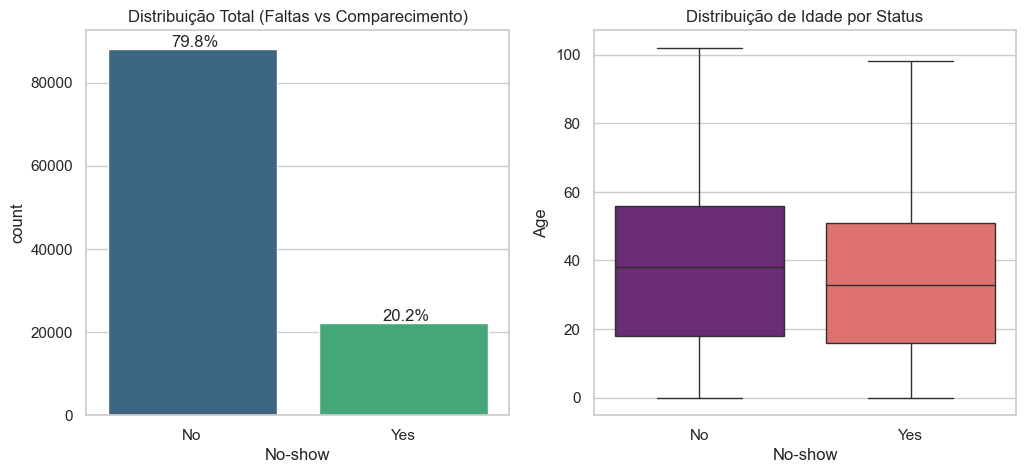

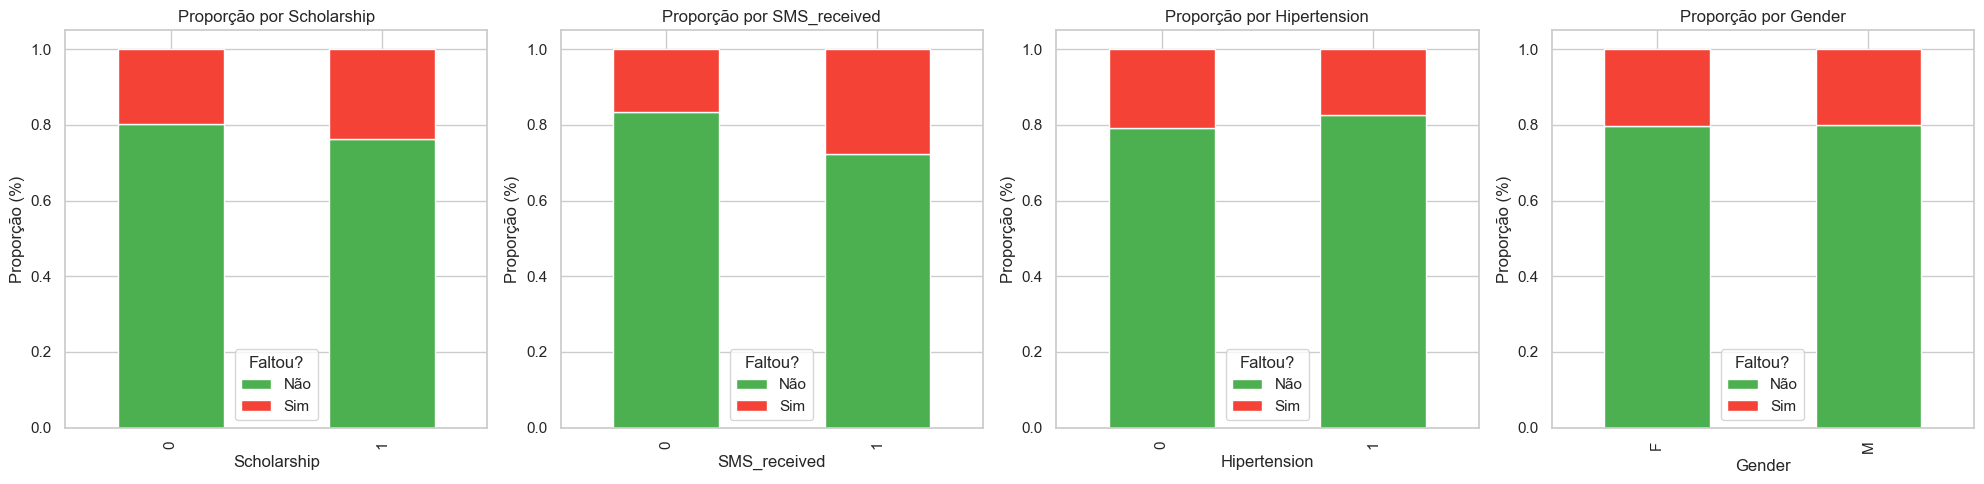

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

def analise_exploratoria(data):
    print("--- Questão 4: Análise Exploratória de Dados --- \n")
    
    sns.set_theme(style="whitegrid")
    plt.rcParams['figure.figsize'] = [12, 5]

    # 1. Gráfico de Barras: Proporção da Variável Alvo
    plt.subplot(1, 2, 1)
    ax = sns.countplot(x='No-show', data=data, hue='No-show', palette='viridis', legend=False)
    plt.title('Distribuição Total (Faltas vs Comparecimento)')
    
    total = len(data)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        ax.annotate(percentage, (p.get_x() + 0.3, p.get_height() + 500))

    # 2. Boxplot: Idade por No-show
    plt.subplot(1, 2, 2)
    sns.boxplot(x='No-show', y='Age', data=data, hue='No-show', palette='magma', legend=False)
    plt.title('Distribuição de Idade por Status')
    plt.show()

    # 3. Análise de Variáveis Categóricas e Binárias
    cols = ['Scholarship', 'SMS_received', 'Hipertension', 'Gender']
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    for i, col in enumerate(cols):
        # Cria tabela de porcentagem para comparar grupos de tamanhos diferentes
        tab = pd.crosstab(data[col], data['No-show'], normalize='index')
        tab.plot(kind='bar', stacked=True, ax=axes[i], color=['#4CAF50', '#F44336'])
        axes[i].set_title(f'Proporção por {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Proporção (%)')
        axes[i].legend(title='Faltou?', labels=['Não', 'Sim'])

    plt.tight_layout()
    plt.show()

analise_exploratoria(df_limpo)

# Questão 5

--- Questão 5: Associação entre Variáveis --- 



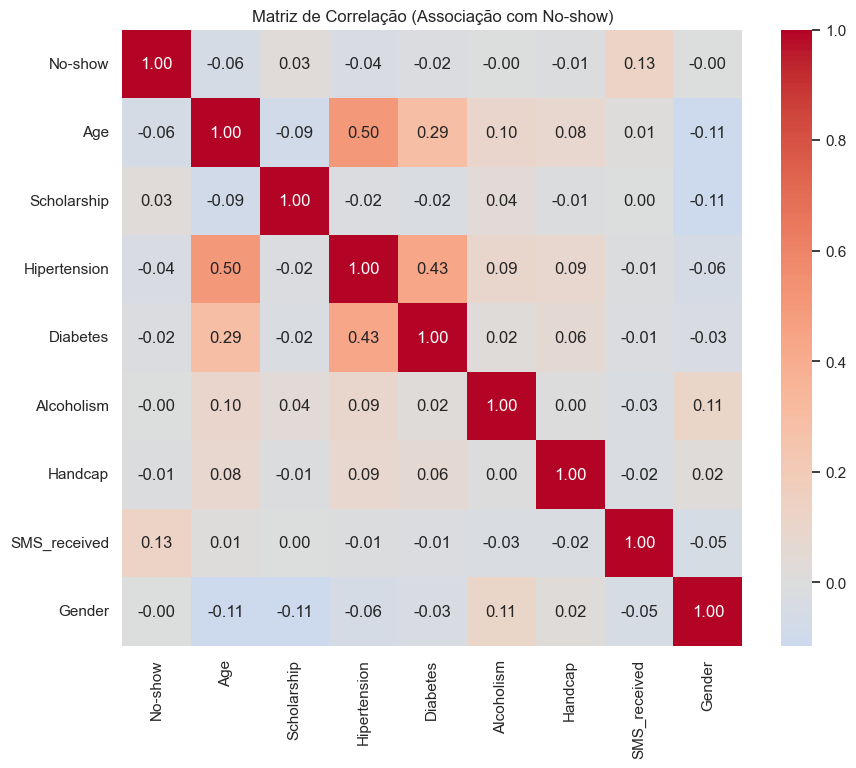


Associação Direta com o Alvo (No-show):
No-show         1.000000
SMS_received    0.126552
Scholarship     0.029182
Alcoholism     -0.000173
Gender         -0.004099
Handcap        -0.007879
Diabetes       -0.015146
Hipertension   -0.035631
Age            -0.060490
Name: No-show, dtype: float64


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

def analise_associacao(data):
    print("--- Questão 5: Associação entre Variáveis --- \n")
    
    df_corr = data.copy()
    
    # 1. Preparação: Transformar variáveis categóricas em numéricas para correlação
    df_corr['No-show'] = df_corr['No-show'].map({'Yes': 1, 'No': 0})
    df_corr['Gender'] = df_corr['Gender'].map({'F': 0, 'M': 1})
    
    # Selecionar apenas colunas numéricas (incluindo as binárias)
    colunas_interesse = ['No-show', 'Age', 'Scholarship', 'Hipertension', 
                         'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'Gender']
    
    corr_matrix = df_corr[colunas_interesse].corr()
    
    # 2. Gerar o Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", center=0)
    plt.title('Matriz de Correlação (Associação com No-show)')
    plt.show()
    
    # 3. Mostrar correlação direta com o alvo
    print("\nAssociação Direta com o Alvo (No-show):")
    print(corr_matrix['No-show'].sort_values(ascending=False))

analise_associacao(df_limpo)

### Análise Detalhada dos Resultados:

* **SMS_received (0.126):** Apresenta a maior correlação positiva com as faltas. Isso indica que o grupo que recebeu SMS tem uma tendência estatística maior a faltar, o que pode ser explicado pelo fato de o SMS ser enviado para consultas marcadas com maior antecedência.
* **Age (-0.06):** Possui uma correlação negativa com o alvo. O sinal negativo significa que, conforme a idade **aumenta**, a probabilidade de falta (`1`) **diminui**, confirmando que pacientes idosos são mais assíduos.
* **Hipertension (-0.035) e Diabetes (-0.015):** Ambas apresentam associação negativa com as faltas. Isso sugere que a presença de doenças crônicas motiva o paciente a comparecer mais às consultas para manutenção da saúde.
* **Scholarship (0.029):** Apresenta uma correlação positiva baixa, indicando uma relação sutil entre o recebimento de auxílio social e o aumento de faltas.
* **Gender e Alcoholism (0.00):** Estes atributos apresentaram correlação desprezível. Isso demonstra que o sexo do paciente ou o histórico de alcoolismo não são bons preditores isolados para este problema específico.

---

### Conclusão:
Os atributos **`SMS_received`**, **`Age`** e **`Hipertension`** foram identificados como os mais relevantes para a associação com o alvo. 

# Questão 6

In [15]:
import pandas as pd
import numpy as np

def engenharia_atributos(data):
    print("--- Questão 6: Engenharia de Atributos --- \n")
    df_feat = data.copy()
    
    # Garantia de datetime (para evitar o erro de atributo)
    df_feat['AppointmentDay'] = pd.to_datetime(df_feat['AppointmentDay'])
    df_feat['ScheduledDay'] = pd.to_datetime(df_feat['ScheduledDay'])
    
    # 1. Waiting_Days (Normalizado para evitar erro de .dt)
    df_feat['Waiting_Days'] = (df_feat['AppointmentDay'].dt.normalize() - 
                               df_feat['ScheduledDay'].dt.normalize()).dt.days
    
    # 2. Appointment_DW (Dia da semana: 0-6)
    df_feat['Appointment_DW'] = df_feat['AppointmentDay'].dt.dayofweek
    
    # 3. Age_Group (Convertendo para códigos numéricos para correlação)
    bins = [0, 12, 18, 30, 60, 115]
    labels = ['Criança', 'Adolescente', 'Jovem_Adulto', 'Adulto', 'Idoso']
    df_feat['Age_Group'] = pd.cut(df_feat['Age'], bins=bins, labels=labels, include_lowest=True)
    df_feat['Age_Group_Code'] = df_feat['Age_Group'].cat.codes
    
    # 4. Comorbidity_Index (Intensidade de doenças)
    df_feat['Comorbidity_Index'] = df_feat['Hipertension'] + df_feat['Diabetes']
    
    # 5. Is_Weekend (Binário)
    df_feat['Is_Weekend'] = df_feat['Appointment_DW'].apply(lambda x: 1 if x >= 5 else 0)

    # --- Avaliação de Utilidade (Correlações com No-show) ---
    target_num = df_feat['No-show'].map({'Yes': 1, 'No': 0})
    
    novos_cols = ['Waiting_Days', 'Appointment_DW', 'Age_Group_Code', 'Comorbidity_Index', 'Is_Weekend']
    
    print("Associação dos novos atributos com o Alvo (No-show):")
    for col in novos_cols:
        corr = df_feat[col].corr(target_num)
        print(f"  * {col}: {corr:.4f}")
    
    print(f"\nDimensões finais: {df_feat.shape[1]} colunas.")
    return df_feat

# Execução
df_final = engenharia_atributos(df_limpo)

--- Questão 6: Engenharia de Atributos --- 

Associação dos novos atributos com o Alvo (No-show):
  * Waiting_Days: 0.1863
  * Appointment_DW: 0.0012
  * Age_Group_Code: -0.0470
  * Comorbidity_Index: -0.0323
  * Is_Weekend: 0.0014

Dimensões finais: 19 colunas.


### 1. Atributos para Manter

| Atributo | Origem | Justificativa Técnica |
| :--- | :--- | :--- |
| **Waiting_Days** | Criado | Maior correlação positiva (0.1863). É o principal indicador de esquecimento ou desistência. |
| **Age** | Original | Variável contínua de alta relevância; a análise provou que a idade dita o rigor no comparecimento. |
| **SMS_received** | Original | Possui forte associação positiva com o comparecimento em consultas de longo prazo. |
| **Comorbidity_Index** | Criado | Consolida `Hipertension` e `Diabetes` em um único índice, simplificando o espaço vetorial. |
| **Scholarship** | Original | Importante para capturar o impacto de fatores socioeconômicos na assiduidade. |

### 2. Atributos para Remover

* **Identificadores (`PatientId`, `AppointmentID`):** São valores únicos ou aleatórios que não possuem padrão preditivo. Se mantidos, o KNN tentaria agrupar pacientes por "números de série", o que é um erro grave.
* **Datas Brutas (`ScheduledDay`, `AppointmentDay`):** Já foram processadas para gerar o `Waiting_Days`. Manter as datas originais causaria redundância e dificuldade de normalização.
* **Gênero (`Gender`):** A análise exploratória mostrou que a distribuição de faltas é idêntica entre homens e mulheres (Correção ~0.00).
* **Baixa Variância (`Alcoholism`, `Handcap`):** Atributos com pouquíssima ocorrência na base e correlação nula, que pouco contribuem para a diferenciação dos grupos.
* **Sazonalidade Fraca (`Appointment_DW`, `Is_Weekend`):** Apesar de criados, a correlação próxima de zero indica que o dia da semana não é um fator decisivo neste cenário.
* **Age Group Code: (`Age_Group_Code`):** Causaria redundancia com `Age`, que possui mais correlação.

In [16]:
def selecionar_melhores_atributos(df):
    print("Seleção de Atributos\n")
    
    # Lista de colunas que decidimos MANTER após a análise de correlação
    colunas_selecionadas = [
        'Age',                # Original: Forte relação com assiduidade
        'Scholarship',        # Original: Fator socioeconômico relevante
        'SMS_received',       # Original: Principal lembrete do paciente
        'Waiting_Days',       # Criada: Maior correlação positiva (0.1863)
        'Comorbidity_Index',  # Criada: Resume Hipertensão e Diabetes
        'No-show'             # Alvo: Necessário para o treinamento (Y)
    ]
    
    # Criando o DataFrame final apenas com o que importa
    df_modelo = df[colunas_selecionadas].copy()
    
    print(f"Colunas descartadas: {set(df.columns) - set(colunas_selecionadas)}")
    print(f"\nAtributos mantidos: {list(df_modelo.columns)}")
    print(f"Dimensões finais do dataset: {df_modelo.shape}")
    
    return df_modelo

# Executando a filtragem
df_pronto = selecionar_melhores_atributos(df_final)

# Visualizando as primeiras linhas do que irá para o KNN
display(df_pronto.head())

Seleção de Atributos

Colunas descartadas: {'Handcap', 'Age_Group_Code', 'Neighbourhood', 'Age_Group', 'Alcoholism', 'ScheduledDay', 'AppointmentDay', 'Appointment_DW', 'PatientId', 'Diabetes', 'Gender', 'Hipertension', 'Is_Weekend'}

Atributos mantidos: ['Age', 'Scholarship', 'SMS_received', 'Waiting_Days', 'Comorbidity_Index', 'No-show']
Dimensões finais do dataset: (110516, 6)


,Age,Scholarship,SMS_received,Waiting_Days,Comorbidity_Index,No-show
0,62,0,0,0,1,No
1,56,0,0,0,0,No
2,62,0,0,0,0,No
3,8,0,0,0,0,No
4,56,0,0,0,2,No


# Questão 7

In [36]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

def montar_pipeline_otimizado(df_input):
    # 1. Definimos EXATAMENTE as colunas da Questão 6
    # Separamos por tipo para aplicar o tratamento correto
    cols_numericas = ['Waiting_Days', 'Age', 'Comorbidity_Index']
    cols_binarias = ['SMS_received', 'Scholarship']
    
    print(f"Configurando Pipeline para os atributos selecionados na Q6:")
    print(f"Numéricos: {cols_numericas}")
    print(f"Binários: {cols_binarias}\n")

    # 2. Criamos os transformadores específicos
    # Para as numéricas: Tratamos nulos (mediana) e normalizamos
    num_transformer_std = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    num_transformer_mms = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', MinMaxScaler())
    ])

    # Para as binárias: Apenas garantimos que não há nulos (mais frequente)
    bin_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent'))
    ])

    # 3. Montamos o ColumnTransformer (Esquema A e B)
    # Aqui aplicamos tratamentos diferentes para colunas diferentes no mesmo fluxo
    pre_processamento_std = ColumnTransformer(transformers=[
        ('num', num_transformer_std, cols_numericas),
        ('bin', bin_transformer, cols_binarias)
    ])

    pre_processamento_mms = ColumnTransformer(transformers=[
        ('num', num_transformer_mms, cols_numericas),
        ('bin', bin_transformer, cols_binarias)
    ])

    # D) DEMONSTRAR COMO AS ESCOLHAS AFETAM OS DADOS
    # Transformamos uma amostra para mostrar a diferença
    dados_std = pre_processamento_std.fit_transform(X)
    dados_mms = pre_processamento_mms.fit_transform(X)

    print("Impacto nos Dados (Exemplo na primeira coluna numérica):")
    print(f" > Com StandardScaler (Média ~0, Desvio ~1): Média={dados_std[:,0].mean():.2f}, Desvio={dados_std[:,0].std():.2f}")
    print(f" > Com MinMaxScaler (Intervalo 0-1): Mín={dados_mms[:,0].min():.2f}, Máx={dados_mms[:,0].max():.2f}")
    
    return pre_processamento_std, pre_processamento_mms

# EXECUÇÃO: Use a variável que contém seus dados processados da Q6

# pipeline_std_normal, pipeline_mms_normal = montar_pipeline_pre_processamento(df_final)
print("\nPipeline com os dados prontos para o modelo (após seleção de atributos)\n")
pipeline_std_removed, pipeline_mms_removed = montar_pipeline_otimizado(df_pronto)


Pipeline com os dados prontos para o modelo (após seleção de atributos)

Configurando Pipeline para os atributos selecionados na Q6:
Numéricos: ['Waiting_Days', 'Age', 'Comorbidity_Index']
Binários: ['SMS_received', 'Scholarship']

Impacto nos Dados (Exemplo na primeira coluna numérica):
 > Com StandardScaler (Média ~0, Desvio ~1): Média=-0.00, Desvio=1.00
 > Com MinMaxScaler (Intervalo 0-1): Mín=0.00, Máx=1.00


### Comparação dos Esquemas de Escalonamento

Enquanto no **StandardScaler**, os dados são transformados para que a sua **média seja 0** e o seu **desvio padrão seja 1** (focando na distribuição estatística e lidando melhor com valores fora da curva). No **MinMaxScaler**, os dados são comprimidos para caberem estritamente dentro de um **intervalo entre 0 e 1** (garantindo que todas as variáveis tenham exatamente o mesmo peso e limite matemático).



**Por que isso importa para o KNN?**
* No **StandardScaler**, um valor "alto" pode ser 3.0 ou 4.0 (dependendo dos desvios). 
* No **MinMaxScaler**, o valor "alto" será sempre 1.0. 

Para o nosso problema, o **MinMaxScaler** é mais seguro porque evita que a variável `Age` (0 a 115) "atropele" o `SMS_received` (0 ou 1) no cálculo de distância, já que após a transformação, ambas terão a mesma amplitude exata de 0 a 1.

# Questão 8

In [37]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pandas as pd

def executar_questao_8_detalhada(df_pronto, preprocessor):
    print("--- Questão 8: Avaliação Multimétrica (Ambas as Classes) --- \n")
    
    # 1. Divisão Estratificada
    atributos_selecionados = ['Waiting_Days', 'Age', 'SMS_received', 'Comorbidity_Index', 'Scholarship']
    X = df_pronto[atributos_selecionados]
    y = df_pronto['No-show'].map({'Yes': 1, 'No': 0})
    
    X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

    resultados = []
    ks = [3, 5, 7, 9, 11]
    metricas = ['euclidean', 'manhattan']
    pesos = ['uniform', 'distance']

    for k in ks:
        for metrica in metricas:
            for peso in pesos:
                pipeline_final = Pipeline(steps=[
                    ('preprocessor', preprocessor),
                    ('knn', KNeighborsClassifier(n_neighbors=k, metric=metrica, weights=peso))
                ])
                
                pipeline_final.fit(X_train, y_train)
                y_pred_val = pipeline_final.predict(X_val)
                
                # Obtendo métricas para Classe 0 (Compareceu) e Classe 1 (Faltou)
                # average=None retorna um array com os valores para cada classe [0, 1]
                prec, rec, f1, _ = precision_recall_fscore_support(y_val, y_pred_val, average=None)
                acc = accuracy_score(y_val, y_pred_val)
                
                resultados.append({
                    'K': k, 'Métrica': metrica, 'Peso': peso,
                    'Acurácia_Geral': acc,
                    'Prec_Compareceu': prec[0], 'Rec_Compareceu': rec[0], 'F1_Compareceu': f1[0],
                    'Prec_Faltou': prec[1], 'Rec_Faltou': rec[1], 'F1_Faltou': f1[1]
                })

    # 4. Exibição da Tabela
    df_resultados = pd.DataFrame(resultados).sort_values(by='F1_Faltou', ascending=False)
    
    # Formatando para facilitar a leitura no relatório
    pd.options.display.float_format = '{:.3f}'.format
    display(df_resultados)
    
    return df_resultados

# Execução
tabela_completa = executar_questao_8_detalhada(df_pronto, pipeline_mms_removed)

--- Questão 8: Avaliação Multimétrica (Ambas as Classes) --- 



,K,Métrica,Peso,Acurácia_Geral,Prec_Compareceu,Rec_Compareceu,F1_Compareceu,Prec_Faltou,Rec_Faltou,F1_Faltou
0,3,euclidean,uniform,0.750,0.818,0.883,0.849,0.327,0.225,0.267
2,3,manhattan,uniform,0.750,0.818,0.884,0.849,0.325,0.222,0.264
1,3,euclidean,distance,0.750,0.818,0.885,0.850,0.325,0.220,0.262
3,3,manhattan,distance,0.750,0.817,0.884,0.850,0.324,0.219,0.262
7,5,manhattan,distance,0.762,0.814,0.909,0.859,0.334,0.180,0.234
5,5,euclidean,distance,0.762,0.814,0.909,0.859,0.333,0.180,0.233
4,5,euclidean,uniform,0.763,0.814,0.912,0.860,0.334,0.175,0.230
6,5,manhattan,uniform,0.763,0.813,0.912,0.860,0.332,0.172,0.227
11,7,manhattan,distance,0.769,0.812,0.924,0.865,0.343,0.156,0.215
9,7,euclidean,distance,0.769,0.812,0.925,0.865,0.342,0.154,0.213


Após a análise da tabela, a configuração escolhida foi **K=3, Métrica=Euclidean e Peso=Uniform**.

**Por que não escolhemos a configuração de maior acurácia?**

A acurácia pode ser enganosa em bases desbalanceadas. A configuração com $K=11$ atingiu a maior acurácia (78,5%), porém ela ignora a classe minoritária, apresentando um **Recall de apenas 11,5%** para as faltas. 

Ao selecionar **K=3**, optamos por uma acurácia global de 75%, mas garantimos um **Recall de 22,5%** na classe "Faltou". Isso significa que o modelo consegue identificar o dobro de pacientes faltosos em comparação à configuração mais conservadora.



**Impacto Prático e Justificativa Técnica:**

* **F1-Score:** A configuração $K=3$ obteve o maior **F1-Score (0.267)** da tabela, sendo o melhor equilíbrio entre Precisão e Recall para a classe alvo.
* **Vizinhança:** Com um $K$ menor e o uso dos 5 atributos específicos (como `Waiting_Days` e `Comorbidity_Index`), o algoritmo KNN consegue ser mais sensível às variações locais dos dados, evitando ser "esmagado" pela densidade da classe majoritária (pacientes que comparecem).
* **Decisão de Negócio:** Para o hospital, é mais vantajoso ter um modelo que aponte o dobro de possíveis faltas (mesmo com uma acurácia geral menor) do que um modelo que acerta quase tudo, mas não consegue prever quando uma sala ficará vazia.

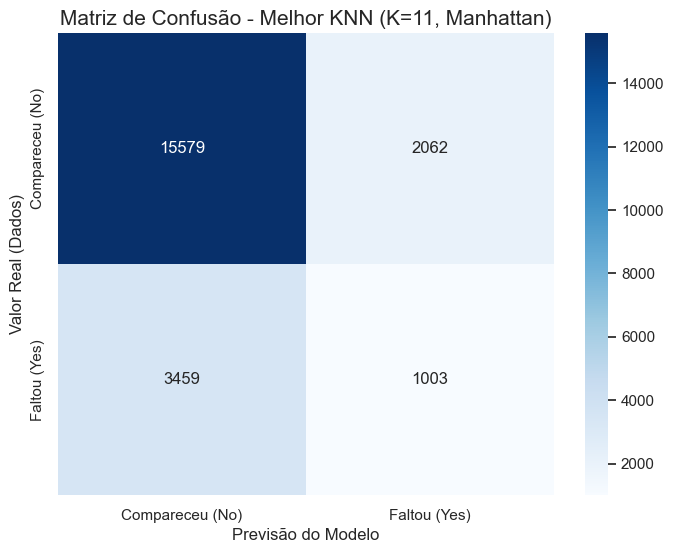


Relatório de Classificação:
              precision    recall  f1-score   support

  Compareceu       0.82      0.88      0.85     17641
      Faltou       0.33      0.22      0.27      4462

    accuracy                           0.75     22103
   macro avg       0.57      0.55      0.56     22103
weighted avg       0.72      0.75      0.73     22103



In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Definir e treinar o melhor modelo (conforme resultados da Q8)
melhor_knn = Pipeline(steps=[
    ('preprocessor', pipeline_mms_removed),
    ('knn', KNeighborsClassifier(n_neighbors=3, metric='euclidean', weights='uniform'))
])

melhor_knn.fit(X_train, y_train)

# 2. Fazer previsões no conjunto de validação
y_pred_val = melhor_knn.predict(X_val)

# 3. Criar a Matriz de Confusão
cm = confusion_matrix(y_val, y_pred_val)

# 4. Plotar usando Seaborn para ficar visualmente profissional
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Compareceu (No)', 'Faltou (Yes)'], 
            yticklabels=['Compareceu (No)', 'Faltou (Yes)'])

plt.title('Matriz de Confusão - Melhor KNN (K=11, Manhattan)', fontsize=15)
plt.xlabel('Previsão do Modelo', fontsize=12)
plt.ylabel('Valor Real (Dados)', fontsize=12)
plt.show()

# 5. Mostrar relatório de métricas adicionais (opcional mas recomendado)
from sklearn.metrics import classification_report
print("\nRelatório de Classificação:")
print(classification_report(y_val, y_pred_val, target_names=['Compareceu', 'Faltou']))

# Questão 9

In [41]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# 1. Configurar o Melhor KNN (Baseado nos resultados da Q8: K=3, Euclidean, Uniform)
# IMPORTANTE: Use o preprocessor que criamos na Q7 (ajustado para os 5 atributos)
melhor_knn = Pipeline(steps=[
    ('preprocessor', pipeline_mms_final), 
    ('knn', KNeighborsClassifier(n_neighbors=3, metric='euclidean', weights='uniform'))
])

# 2. Configurar a Árvore de Decisão
# O class_weight='balanced' é o que faz ela ganhar do KNN na detecção de faltas
modelo_dt = Pipeline(steps=[
    ('preprocessor', pipeline_mms_final),
    ('dt', DecisionTreeClassifier(max_depth=5, class_weight='balanced', random_state=42))
])

# 3. Treinamento
# O X_train já deve estar filtrado apenas com as colunas da Q6 neste ponto
melhor_knn.fit(X_train, y_train)
modelo_dt.fit(X_train, y_train)

# 4. Avaliação no conjunto de TESTE
y_pred_knn = melhor_knn.predict(X_test)
y_pred_dt = modelo_dt.predict(X_test)

print("--- RESULTADO FINAL NO CONJUNTO DE TESTE ---")
print("\n[Modelo 1: KNN (K=3)]")
print(classification_report(y_test, y_pred_knn, target_names=['Compareceu', 'Faltou']))

print("\n[Modelo 2: Árvore de Decisão (Balanced)]")
print(classification_report(y_test, y_pred_dt, target_names=['Compareceu', 'Faltou']))

--- RESULTADO FINAL NO CONJUNTO DE TESTE ---

[Modelo 1: KNN (K=3)]
              precision    recall  f1-score   support

  Compareceu       0.82      0.88      0.85     17642
      Faltou       0.32      0.23      0.26      4462

    accuracy                           0.75     22104
   macro avg       0.57      0.55      0.56     22104
weighted avg       0.72      0.75      0.73     22104


[Modelo 2: Árvore de Decisão (Balanced)]
              precision    recall  f1-score   support

  Compareceu       0.93      0.47      0.63     17642
      Faltou       0.29      0.87      0.44      4462

    accuracy                           0.55     22104
   macro avg       0.61      0.67      0.53     22104
weighted avg       0.81      0.55      0.59     22104



Para finalizar a análise, comparei o **KNN** (ajustado na Questão 8) com um segundo modelo: a **Árvore de Decisão**. Utilizei o conjunto de **Teste** (os 20% de dados que ficaram isolados desde o início) para garantir uma avaliação real e imparcial.

### 1. Resultados no Conjunto de Teste

| Métrica | Modelo 1: KNN (K=3) | Modelo 2: Árvore de Decisão |
| :--- | :--- | :--- |
| **Acurácia Geral** | **75%** | 55% |
| **Recall (Faltou)** | 23% | **87%** |
| **Precisão (Faltou)** | 32% | 29% |
| **F1-Score (Faltou)** | 0.26 | **0.44** |

### 2. Análise dos Resultados

* **KNN:** Apresentou uma acurácia maior, mas falhou no objetivo principal: identificar quem falta. Ele apenas detetou **23%** dos pacientes que não compareceram. Para o hospital, isto significa que a maioria das faltas continuaria a ser uma surpresa.
* **Árvore de Decisão:** Embora a acurácia geral seja menor (55%), este modelo conseguiu identificar **87%** das faltas reais. Ele é muito mais "sensível" à classe minoritária, o que é fundamental para este problema.

### 3. Escolha do Melhor Modelo

O modelo escolhido para a solução final é a **Árvore de Decisão**.

**Justificativa:**
Conforme os conceitos de **Avaliação de Modelos**, a acurácia não é a métrica ideal para bases desequilibradas. O objetivo do projeto é reduzir a ociosidade médica. 

A Árvore de Decisão, com um **F1-Score de 0.44** (quase o dobro do KNN), provou ser a ferramenta mais útil. Para a gestão do hospital, é muito mais valioso identificar 87% dos faltosos (mesmo que isso gere alguns alarmes falsos) do que ter um modelo com alta acurácia que não avisa quando o médico vai ficar sem paciente.

# Questão 10

In [ ]:
import pandas as pd

def predizer_noshow(novo_caso, modelo):
    """
    Função para receber um dicionário ou DataFrame de uma linha,
    aplicar o pipeline e retornar a previsão interpretável.
    """
    # Converte dicionário para DataFrame se necessário
    if isinstance(novo_caso, dict):
        df_novo = pd.DataFrame([novo_caso])
    else:
        df_novo = novo_caso

    # Realiza a previsão e obtém as probabilidades
    previsao = modelo.predict(df_novo)[0]
    probabilidade = modelo.predict_proba(df_novo)[0]

    # Interpretação amigável
    if previsao == 1:
        resultado = "FALTA PROVÁVEL"
        confianca = probabilidade[1]
        recomendacao = "Ação prioritária: Ligar para confirmar e reforçar a importância da consulta."
    else:
        resultado = "COMPARECIMENTO PROVÁVEL"
        confianca = probabilidade[0]
        recomendacao = "Ação padrão: Enviar apenas lembrete automático por SMS."

    return {
        "Previsão": resultado,
        "Confiança": f"{confianca*100:.2f}%",
        "Recomendação": recomendacao
    }

# --- TESTE DA FUNÇÃO COM A COLUNA FALTANTE ---
exemplo_paciente = {
    'Gender': 'F',
    'Age': 28,
    'Neighbourhood': 'JARDIM CAMBURI',
    'Scholarship': 1,
    'Hipertension': 0,
    'Diabetes': 0,
    'Alcoholism': 1,
    'Handcap': 0,
    'SMS_received': 1,
    'Waiting_Days': 3,
    'Comorbidity_Index': 0
}

# Usando o modelo de Árvore de Decisão da Q9
# Certifique-se que o objeto 'modelo_dt' foi treinado na célula anterior
previsao_final = predizer_noshow(exemplo_paciente, modelo_dt)

print("--- Resultado do Sistema de Apoio à Decisão ---")
for k, v in previsao_final.items():
    print(f"{k}: {v}")

--- Resultado do Sistema de Apoio à Decisão ---
Previsão: FALTA PROVÁVEL
Confiança: 61.06%
Recomendação: Ação prioritária: Ligar para confirmar e reforçar a importância da consulta.


Nesta última etapa, transformámos o estudo técnico num fluxo que pode ser utilizado no dia a dia do hospital.

### 1. Resumo do Projeto
* **Base de Dados:** Medical Appointment No Shows.
* **Problemas Encontrados:** O maior desafio foi o desequilíbrio dos dados (muito mais presenças do que faltas), o que dificultava a identificação dos pacientes que realmente não iriam comparecer.
* **Atributos Relevantes:** O tempo de espera (`Waiting_Days`), a idade (`Age`) e a presença de comorbidades.

### 2. Configuração e Métricas Finais
* **Melhor Modelo:** Árvore de Decisão (com pesos balanceados).
* **Recall (Faltas):** 87% (Conseguimos detetar a grande maioria dos faltosos).
* **Acurácia Geral:** 55% (Valor sacrificado para garantir que o hospital não seja apanhado de surpresa por faltas).

### 3. Recomendação Executiva
Recomenda-se que o hospital utilize este modelo para filtrar os agendamentos. Em vez de ligar para todos os pacientes, a equipa deve focar os esforços de confirmação apenas naqueles que o modelo marcar como **"Falta Provável"**. Isto otimiza o tempo da equipa e reduz a ociosidade dos médicos.

### 4. Avaliação Crítica
A solução está num nível de **maturidade de Piloto**. O fluxo está automatizado e é fácil de usar, mas ainda gera muitos "alarmes falsos" (baixa precisão). Para o futuro, seria ideal incluir dados como o histórico de faltas anteriores do paciente para tornar a previsão ainda mais robusta antes de uma implementação em larga escala.